## Deutsch-Jozsa Algorithm (n-qubit)

Given a black-box function f(x) that is either *constant* (same output for all inputs)
or *balanced* (outputs 0 for half, 1 for the other half) — classically we need
up to 2^(n-1)+1 queries to be sure. DJ does it in exactly **one**.

This notebook includes the general n-qubit case where:
- The user defines n and provides a function (e.g. `x0 xor x2`)
- The oracle is built dynamically from the input using CX gates
- Measuring all |0⟩s → constant, anything else → balanced

Enter the number of input qubits (n):  5
Enter a function using x0 to x4 (e.g., 'x0 xor x4'):
 x0xorx2xorx4


 Oracle: Balanced function. Added CX gates with controls [0, 2, 4]

Generated Circuit Diagram:


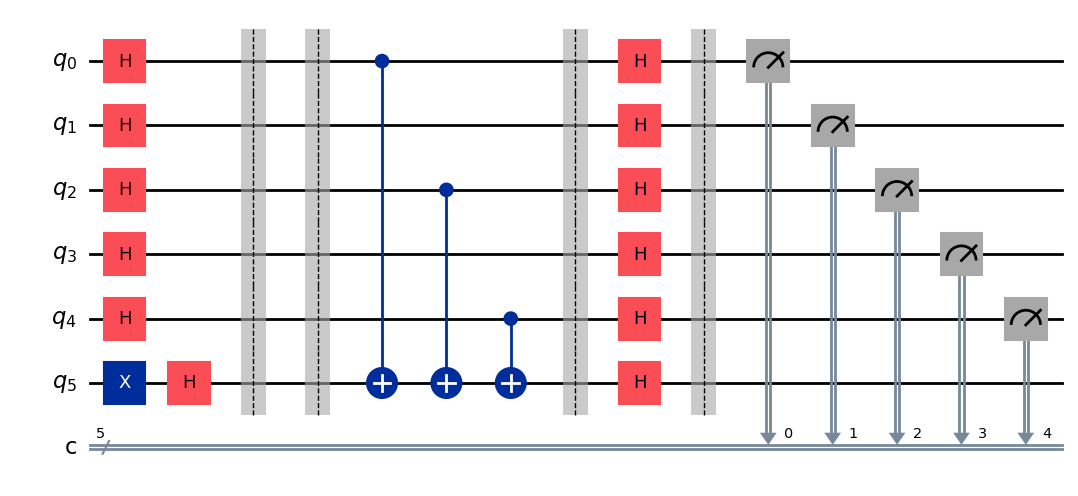

In [31]:
import matplotlib.pyplot as plt
import re
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_bloch_multivector, plot_histogram

try:
    n = int(input("Enter the number of input qubits (n): "))
    user_input = input(f"Enter a function using x0 to x{n-1} (e.g., 'x0 xor x{n-1}'):\n")
except ValueError:
    print("Please enter a valid integer for n.")
    exit()

def oracle(circuit, func_str, n_inputs):
   
    ancilla = n_inputs
    clean_func = func_str.lower().replace(" ", "")
    indices = re.findall(r'x(\d+)', clean_func)
    
    # Filter: Only take indices that actually exist in our input register
    control_qubits = [int(i) for i in indices if int(i) < n_inputs]
    
    if not control_qubits:
        print(f" Oracle: Constant function detected (or no valid inputs).")
        return

    circuit.barrier()
    for q_idx in control_qubits:
        circuit.cx(q_idx, ancilla)
    circuit.barrier()
    print(f" Oracle: Balanced function. Added CX gates with controls {control_qubits}")

def blochSphere(circuit: QuantumCircuit):
   
    qc = circuit.copy()               
    qc.save_statevector()            

    sim = AerSimulator(method='statevector')
    tqc = transpile(qc, sim)
    result = sim.run(tqc).result()

    state = result.get_statevector(tqc)    
    fig = plot_bloch_multivector(state)   
    plt.show()
    return fig

def histogramRep(circuit: QuantumCircuit, shots: int = 1024):
   
    qch = circuit.copy()            
    qch.measure_all()                 

    sim = AerSimulator()
    tqc = transpile(qch, sim)
    result = sim.run(tqc, shots=shots).result()

    counts = result.get_counts()
    fig = plot_histogram(counts)      
    plt.show()
    return fig

# --- Circuit Construction ---

# Total qubits = n (inputs) + 1 (ancilla). Classical bits = n (to measure results)
DJ = QuantumCircuit(n + 1, n)

# 1. State Preparation
DJ.x(n)              # Put ancilla in |1>
DJ.h(range(n + 1))   # Put all qubits in superposition (ancilla becomes |->)
DJ.barrier()

# 2. Apply Oracle
oracle(DJ, user_input, n)

# 3. Final Walsh-Hadamard on input qubits
DJ.h(range(n+1))
DJ.barrier()

# 4. Measurement
DJ.measure(range(n), range(n))

# --- Visualization ---
print("\nGenerated Circuit Diagram:")
display(DJ.draw('mpl')) # Use DJ.draw('mpl') and plt.show() if not in a notebook
plt.show()

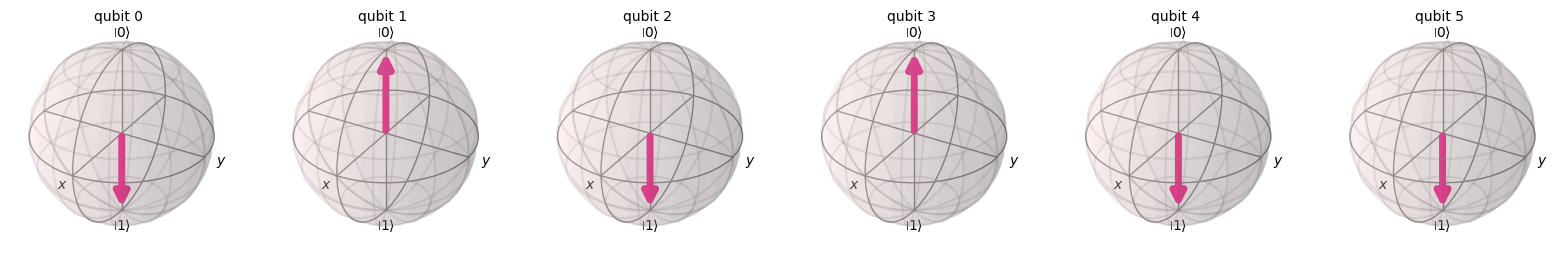

In [33]:
blochSphere(DJ)

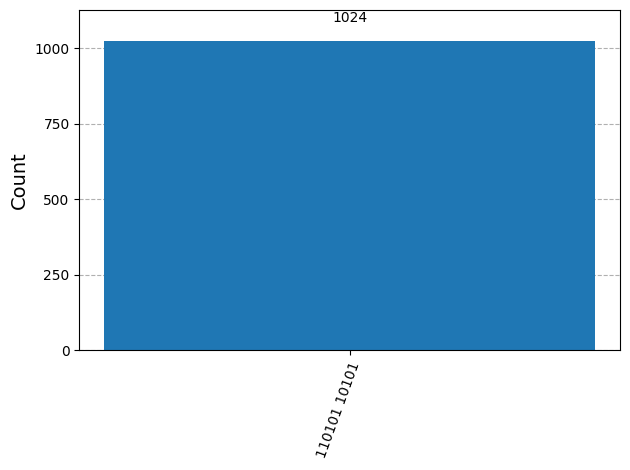

In [35]:
histogramRep(DJ)